In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("Fraud_Analysis_Dataset.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [8]:
df['isFraud'].value_counts()

isFraud
0    10000
1     1142
Name: count, dtype: int64

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [10]:
df.shape

(11142, 10)

In [11]:
(df['isFraud'].value_counts()[1]/ df.shape[0]) * 100

np.float64(10.249506372285047)

In [12]:
df['type'].value_counts()

type
PAYMENT     5510
CASH_IN     1951
CASH_OUT    1871
TRANSFER    1464
DEBIT        346
Name: count, dtype: int64

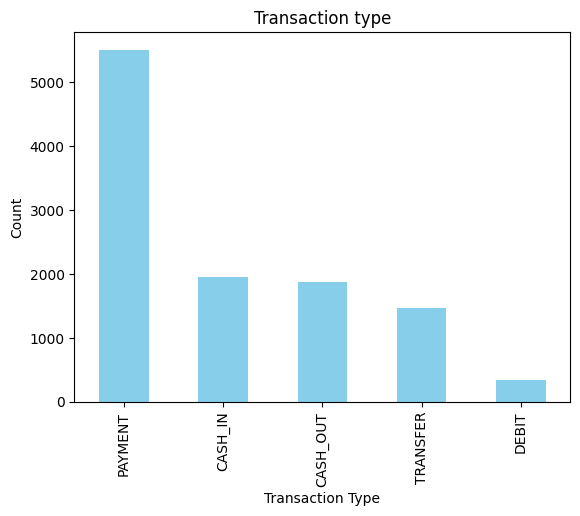

In [13]:
df['type'].value_counts().plot(kind='bar',title='Transaction type',color = 'skyblue')
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

Distribution of Transaction Types by Fraud Status

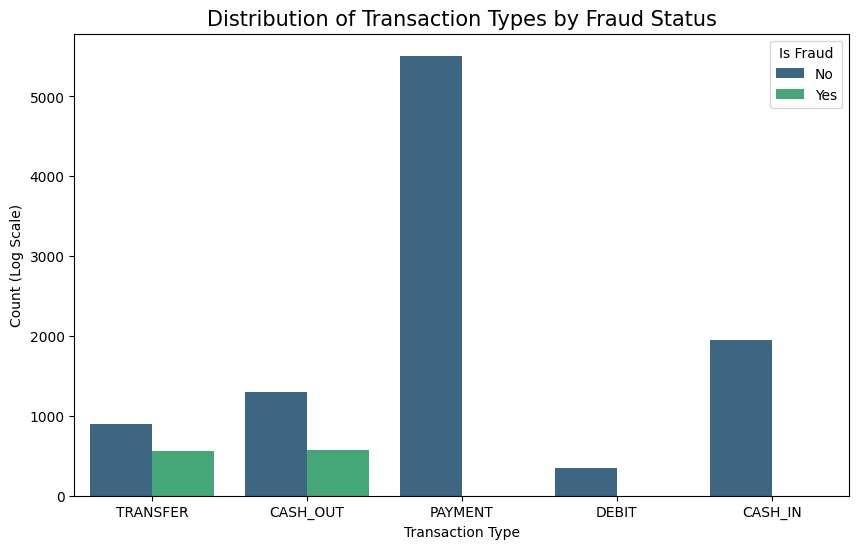

In [14]:
plt.figure(figsize=(10, 6))
# Create a count plot to show frequency of transaction types
sns.countplot(x='type', hue='isFraud', data=df, palette='viridis')
plt.title('Distribution of Transaction Types by Fraud Status', fontsize=15)
plt.xlabel('Transaction Type')
plt.ylabel('Count (Log Scale)')
# Use log scale because non-fraud counts are huge compared to fraud
# plt.yscale('log') 
plt.legend(title='Is Fraud', labels=['No', 'Yes'])
plt.show()

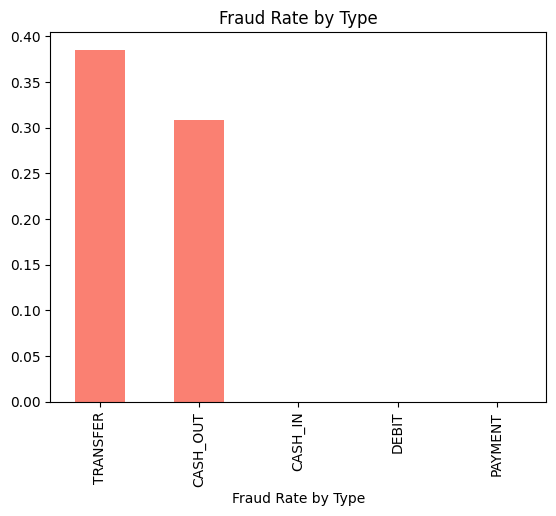

In [15]:
fraud_by_type = df.groupby('type')["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar',title='Fraud Rate by Type',color='salmon')
plt.xlabel("Fraud Rate by Type")
plt.show()

In [16]:
fraud_by_type

type
TRANSFER    0.385246
CASH_OUT    0.308926
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [17]:
df['amount'].describe().astype(int)

count       11142
mean       213191
std        760065
min             2
25%          4946
50%         16761
75%        154336
max      10000000
Name: amount, dtype: int64

Transaction Amount Distribution (Fraud vs Non-Fraud)


C:\Users\nitis\AppData\Local\Temp\ipykernel_21548\742039300.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')


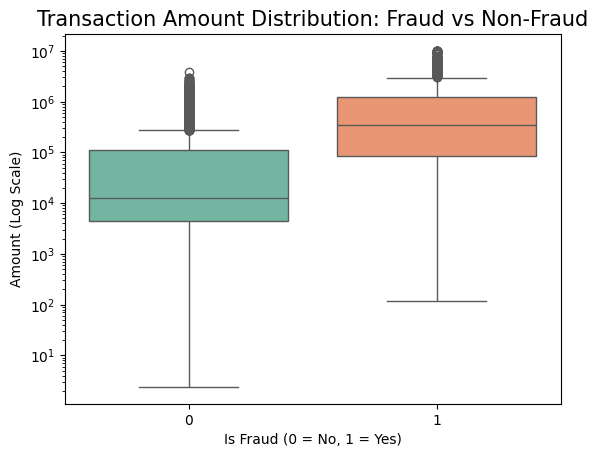

In [18]:
sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')
plt.title('Transaction Amount Distribution: Fraud vs Non-Fraud', fontsize=15)
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Amount (Log Scale)')
# Log scale helps to visualize the spread better as amounts vary wildly
plt.yscale('log')
plt.show()

In [19]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [35]:
corr = df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

Correlation Heatmap

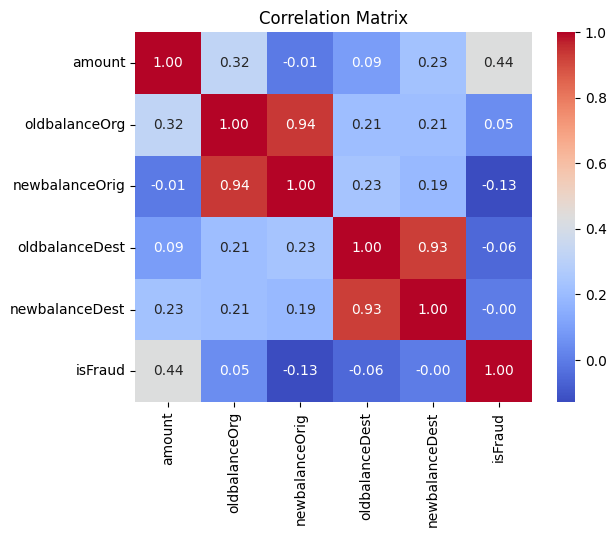

In [36]:
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Time-Series Analysis (Step vs Fraud)

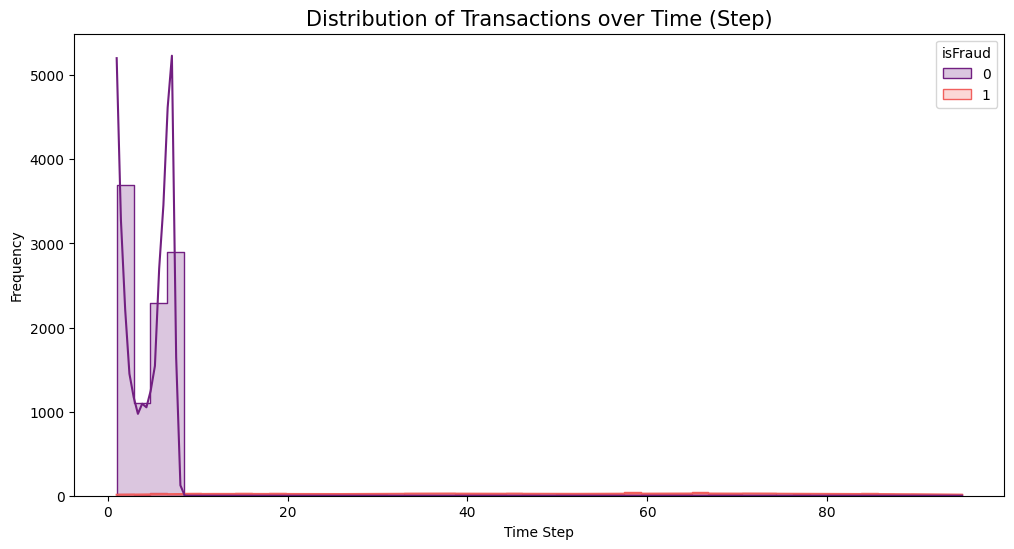

In [21]:
plt.figure(figsize=(12, 6))
# Histogram with a Kernel Density Estimate (KDE) to show the shape of distribution
sns.histplot(data=df, x='step', hue='isFraud', kde=True, bins=50, palette='magma', element="step")
plt.title('Distribution of Transactions over Time (Step)', fontsize=15)
plt.xlabel('Time Step')
plt.ylabel('Frequency')
plt.show()

Explanation of Each Diagram:

Transaction Types: This bar chart shows which transaction types (e.g., TRANSFER, CASH_OUT) have fraud. The yscale('log') is crucial here because legitimate transactions vastly outnumber fraudulent ones, making the fraud bars invisible without it.

Amount Distribution: The boxplot compares the range of money transferred in fraud vs. non-fraud cases. It highlights that fraudulent transactions often have specific amount ranges.

Correlation Heatmap: This helps identify which numerical features are related. For example, you might see a relationship between oldbalanceOrg and newbalanceOrig.

Time Distribution: This checks if fraud spikes at specific "steps" (time intervals), which could indicate a coordinated attack during certain hours.

The "Account Emptying" Pattern (Scatter Plot)

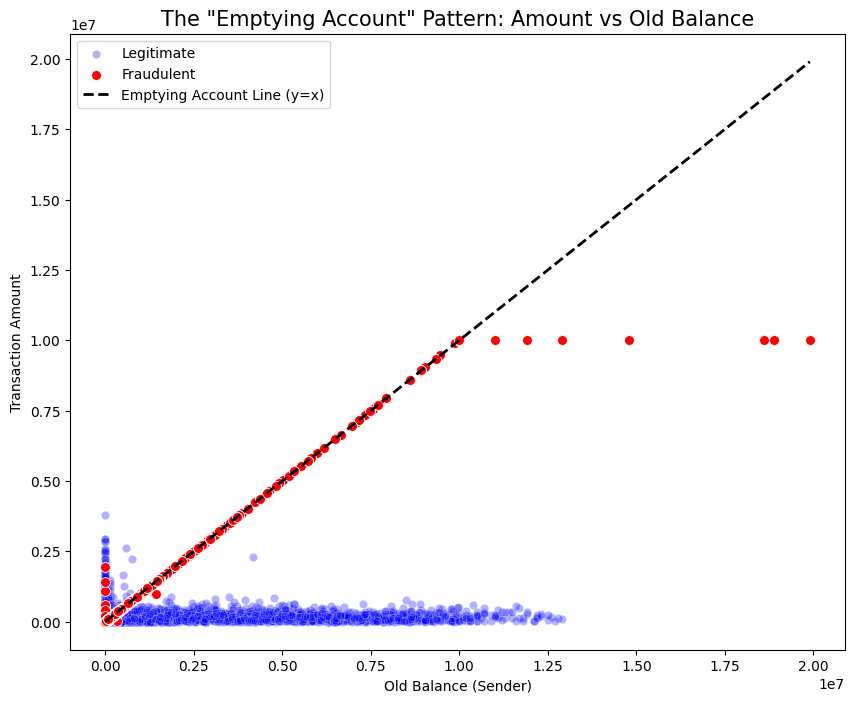

In [22]:
plt.figure(figsize=(10, 8))
# Plot Non-Fraud first (blue)
sns.scatterplot(data=df[df['isFraud']==0], x='oldbalanceOrg', y='amount', 
                color='blue', alpha=0.3, label='Legitimate')
# Plot Fraud on top (red)
sns.scatterplot(data=df[df['isFraud']==1], x='oldbalanceOrg', y='amount', 
                color='red', s=50, label='Fraudulent')

# Add a diagonal line (y=x) to show where Amount equals Balance
max_val = max(df['oldbalanceOrg'].max(), df['amount'].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Emptying Account Line (y=x)')

plt.title('The "Emptying Account" Pattern: Amount vs Old Balance', fontsize=15)
plt.xlabel('Old Balance (Sender)')
plt.ylabel('Transaction Amount')
plt.legend()
plt.show()

Fraud by Destination Type (Merchant vs Customer)

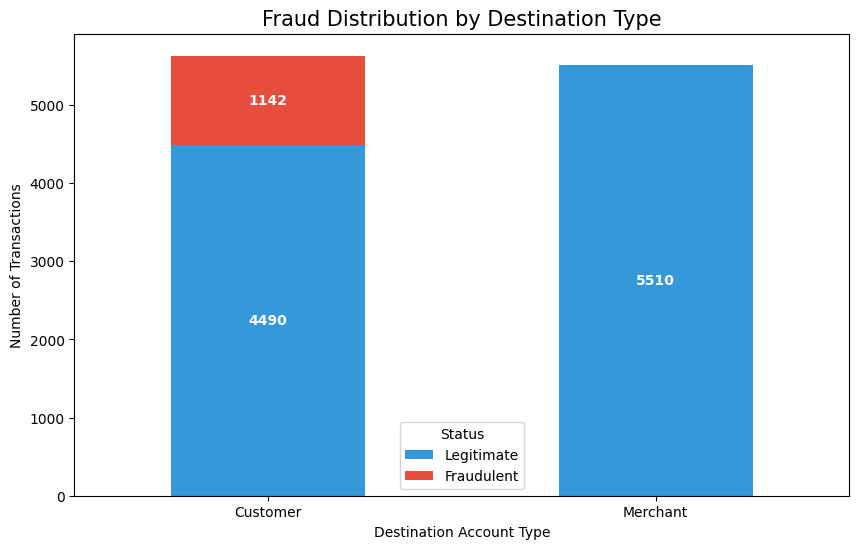

In [23]:
df['destType'] = df['nameDest'].apply(lambda x: 'Merchant' if x.startswith('M') else 'Customer')

# Calculate counts
fraud_counts = df.groupby(['destType', 'isFraud']).size().unstack(fill_value=0)

# Plot
ax = fraud_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#3498db', '#e74c3c'])
plt.title('Fraud Distribution by Destination Type', fontsize=15)
plt.ylabel('Number of Transactions')
plt.xlabel('Destination Account Type')
plt.xticks(rotation=0)
plt.legend(['Legitimate', 'Fraudulent'], title='Status')

# Add text labels
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x+width/2, y+height/2, f'{int(height)}', ha='center', va='center', color='white', fontweight='bold')
plt.show()

What these diagrams will show you:

Scatter Plot: You will see the red dots (Fraud) lining up perfectly on the diagonal dashed line. This visually proves that fraudsters are calculating the exact balance to drain the account.

Bar Chart: You will see a big red bar for "Customer" and no red bar for "Merchant". This is a great rule for a fraud prevention system: "If destination is Merchant, risk is low."

Box Plot (Balance Error): You might see that for legitimate transactions, the error is close to 0 (the math works). For fraud, there might be huge errors, meaning the system recorded the transaction weirdly (e.g., money sent but balance not deducted properly).

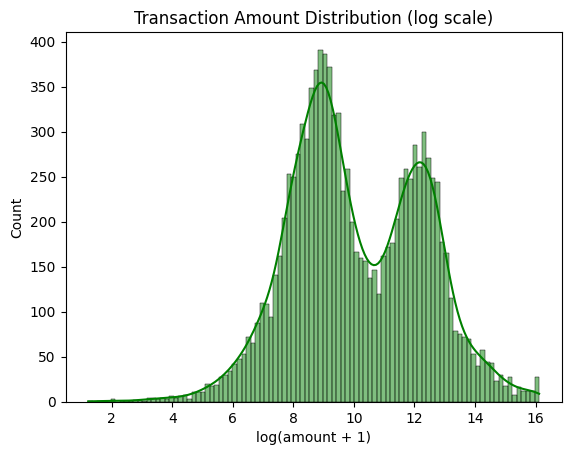

In [24]:

sns.histplot(np.log1p(df['amount']),bins=100,kde=True, color='green')
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("log(amount + 1)")
plt.show()


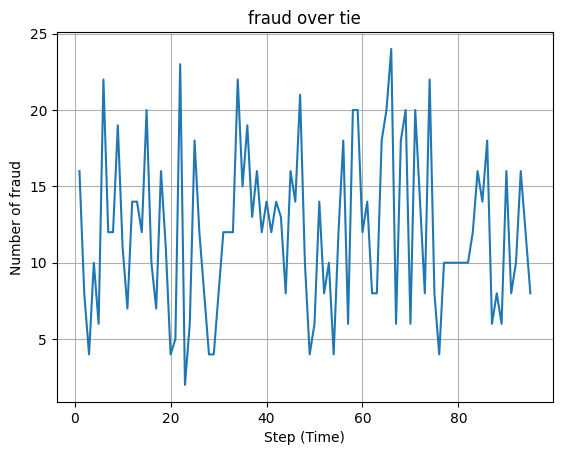

In [ ]:
fraud_per_step = df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index,fraud_per_step.values,label='fraud per step')
plt.xlabel("Step (Time)")
plt.ylabel("Number of fraud")
plt.title("fraud over time")
plt.grid()
plt.show()

In [37]:
df.drop(columns="step",inplace=True)

In [26]:
top_senders =df['nameOrig'].value_counts().head(10)

In [27]:
top_senders

nameOrig
C1637966097    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C548454569     1
C1190697059    1
C1867037662    1
C965014368     1
Name: count, dtype: int64

In [28]:
top_receivers=df['nameDest'].value_counts().head(10)

In [29]:
top_receivers

nameDest
C985934102     62
C1590550415    52
C1286084959    50
C1899073220    44
C977993101     44
C1782113663    43
C451111351     43
C2083562754    41
C1789550256    40
C1360767589    40
Name: count, dtype: int64

In [30]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"])
)]

In [31]:
len(zero_after_transfer)

1791

In [33]:
zero_after_transfer.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,destType
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,Customer
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,Customer
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,Customer
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,Customer
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,Customer


In [34]:
df['isFraud'].value_counts()

isFraud
0    10000
1     1142
Name: count, dtype: int64

In [38]:
# Select Features (X) and Target (y)
X = df[['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
y = df['isFraud']

In [39]:
# Numerical Columns: Scale them
numeric_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
numeric_transformer = StandardScaler()

In [40]:
# Categorical Columns: OneHotEncode 'type'
categorical_features = ['type']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [41]:
# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [43]:
# 4. Create Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42)) 
])

In [44]:
# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
# 6. Train the Model
print("Training model with destination balances...")
model.fit(X_train, y_train)

Training model with destination balances...


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
# 7. Evaluate
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9941677882458502

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       0.99      0.96      0.97       228

    accuracy                           0.99      2229
   macro avg       0.99      0.98      0.98      2229
weighted avg       0.99      0.99      0.99      2229



In [50]:
from sklearn.linear_model import LogisticRegression

model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000)) 
])

In [51]:
print("Training Logistic Regression model...")
model2.fit(X_train, y_train)

Training Logistic Regression model...


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred = model2.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9520

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2001
           1       0.99      0.54      0.70       228

    accuracy                           0.95      2229
   macro avg       0.97      0.77      0.83      2229
weighted avg       0.95      0.95      0.95      2229


Confusion Matrix:
[[2000    1]
 [ 106  122]]


In [54]:
from sklearn.ensemble import GradientBoostingClassifier
model3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3))
])


In [55]:
print("Training Gradient Boosting model...")
model3.fit(X_train, y_train)

Training Gradient Boosting model...


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy: 0.9928

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       0.97      0.96      0.96       228

    accuracy                           0.99      2229
   macro avg       0.98      0.98      0.98      2229
weighted avg       0.99      0.99      0.99      2229



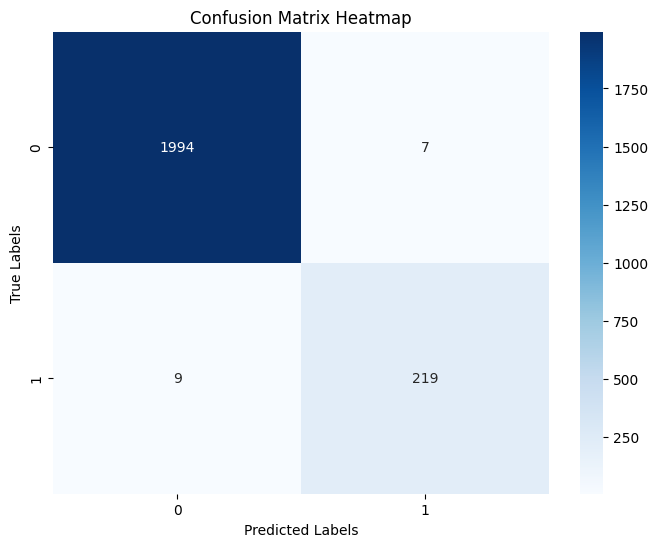

In [56]:
y_pred = model3.predict(X_test)

# 3. Print Text-Based Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model3.classes_, 
            yticklabels=model3.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [60]:
from xgboost import XGBClassifier

model4 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, scale_pos_weight=9, random_state=42))
])


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
model4.fit(X_train, y_train)

y_pred = model4.predict(X_test)
from sklearn.metrics import classification_report
print("XGBoost Pipeline Result:")
print(classification_report(y_test, y_pred))

In [64]:
from sklearn.pipeline import Pipeline
import joblib
joblib.dump(Pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']